# ACT Comparison FMCW, EEG, and EMG pipelines

In [16]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import mne
from scipy.io import loadmat
import sys
import Original_Code.old_act as act_cpu_lib

sys.path.append("../..")
import act as act_cpu_lib_2

## FMCW Pipeline

In [2]:
FS = 256 / 0.015
order = 5
lowcut = 10
highcut = int(FS/2)
tc_info = (0, 256, 16)
fc_info = (lowcut, highcut, 100)
logDt_info = (-4, 0, 0.3)
c_info = (-10, 10, 0.75)

In [ ]:
data = np.load("../Data/data_SAAB_SIRS_77GHz_FMCW.npy", allow_pickle=True)
segment = data[0,1][:,0]
segment = np.abs(segment[512:768]).astype(np.float32)
b,a = butter(4,[lowcut/(FS/2), highcut/(FS/2)],btype='band')
segment = filtfilt(b,a,segment)
epoch_length = len(segment)
t = np.arange(epoch_length)/FS

Dictionary length: 520128


/Users/nishant/Documents/GitHub/acttesting/Testing Scripts/../act_var1.py:58: RuntimeWarning: overflow encountered in exp
  Dt = np.exp(logDt)
/Users/nishant/Documents/GitHub/acttesting/Testing Scripts/../act_var1.py:58: RuntimeWarning: overflow encountered in exp
  Dt = np.exp(logDt)


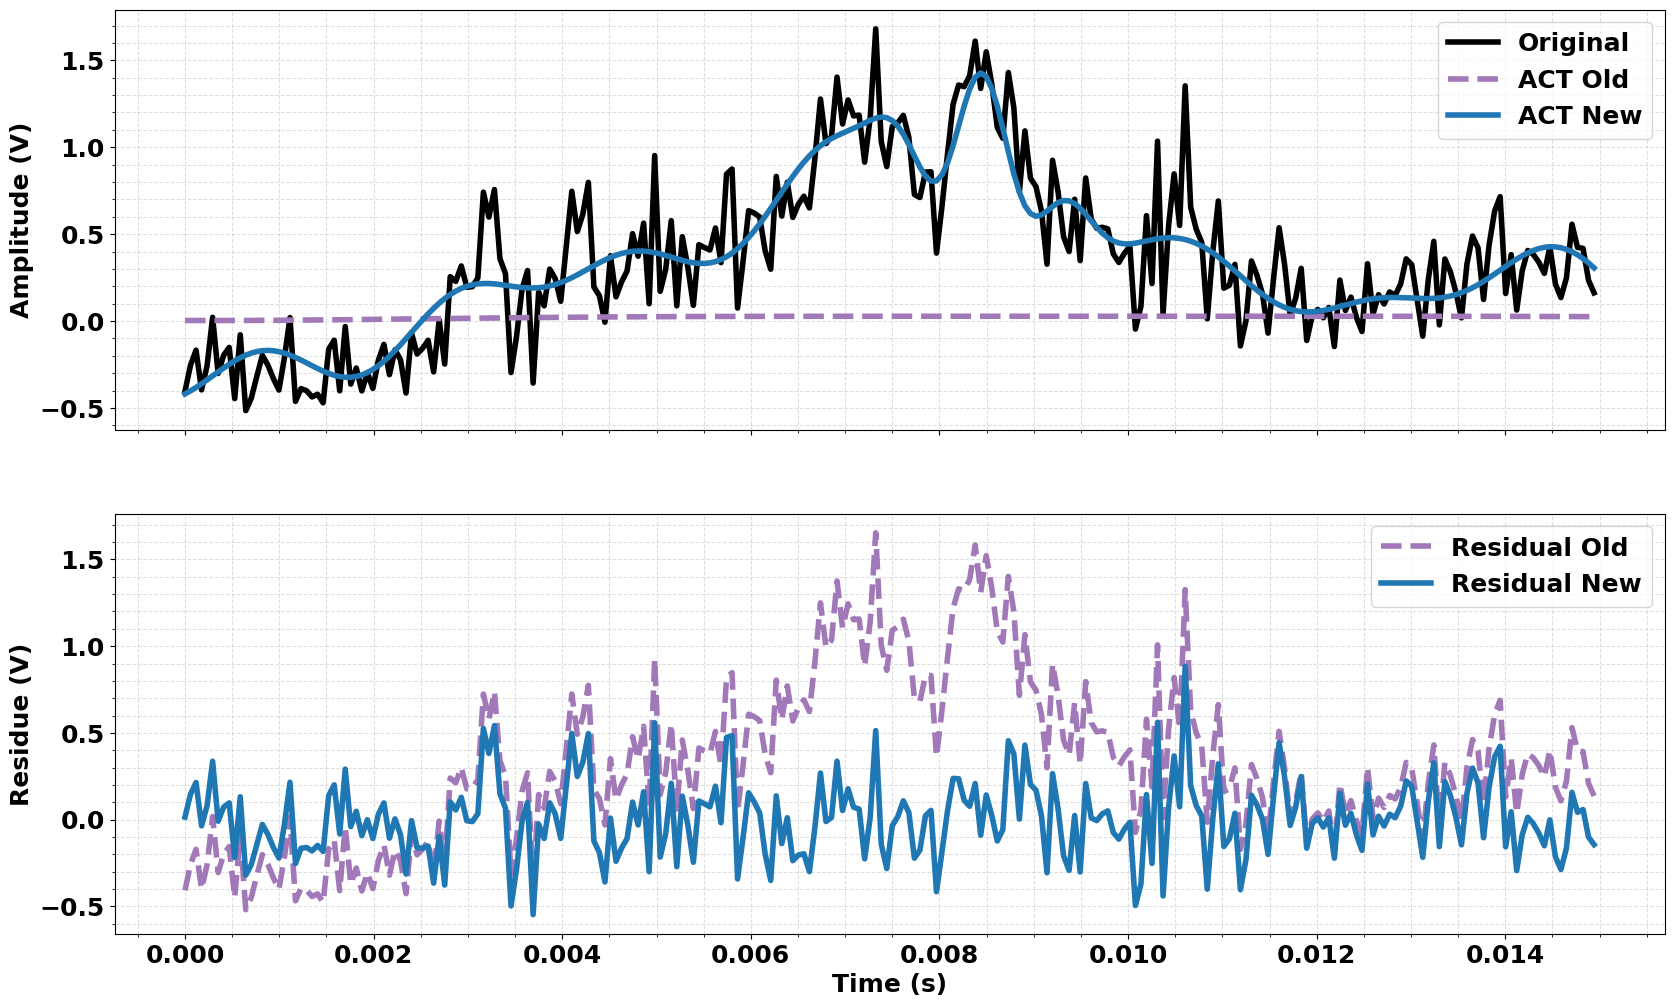

In [4]:
act_old = act_cpu_lib.ACT(FS=FS, length=epoch_length,
                          tc_info=tc_info, fc_info=fc_info,
                          logDt_info=logDt_info, c_info=c_info,
                          force_regenerate=True, mute=True)
act_new = act_cpu_lib_2.ACT(FS=FS, length=epoch_length,
                            tc_info=tc_info, fc_info=fc_info,
                            logDt_info=logDt_info, c_info=c_info,
                            force_regenerate=True, mute=True)
out_old = act_old.transform(segment,order=order, debug=False)
out_new = act_new.transform(segment,order=order, debug=False)
plt.rcParams.update({'font.size': 18, 'font.weight': 'bold'})
fig,axs = plt.subplots(2,1,figsize=(20,12), sharex= True)
axs[0].minorticks_on()
axs[0].grid(True, which='both', linestyle='--', linewidth=0.75, alpha=0.4)
axs[0].plot(t,out_old['signal'],label='Original', linewidth=4, color='black')
axs[0].plot(t,out_old['approx'],'--',label='ACT Old', linewidth=4, color="#A178B8")
axs[0].plot(t,out_new['approx'],label='ACT New', linewidth=4, color='tab:blue')
axs[0].set_ylabel('Amplitude (V)', fontweight='bold')

axs[1].minorticks_on()
axs[1].grid(True, which='both', linestyle='--', linewidth=0.75, alpha=0.4)
axs[1].plot(t,out_old['residue'],'--',label='Residual Old', linewidth=4, color="#A178B8")
axs[1].plot(t,out_new['residue'],label='Residual New', linewidth=4, color='tab:blue')
axs[1].set_ylabel('Residue (V)', fontweight='bold')
axs[1].set_xlabel('Time (s)', fontweight='bold')

for ax in axs:
    ax.legend()
plt.show()

## EEG Pipeline

In [5]:
FS = 256
epoch_length = FS
channels = ['HB_1']
order = 5
tc_info = (0, epoch_length, 16)
fc_info = (0.5, 15, 0.5)
logDt_info = (-4, 1, 0.5)
c_info = (-10, 10, 0.5)

In [ ]:
data_file = os.path.join(os.getcwd(), '../Data/sub-1_task-Sleep_acq-headband_eeg.edf')
raw = mne.io.read_raw_edf(data_file, preload=True, verbose=False)
raw.pick_channels(channels)
raw.notch_filter(50, verbose=False)
raw.filter(l_freq=0.1, h_freq=20.0, verbose=False)
eeg = raw.get_data().T.astype(np.float32)
segment = eeg[:epoch_length,0]
t = np.arange(len(segment))/FS

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


Dictionary length: 185600


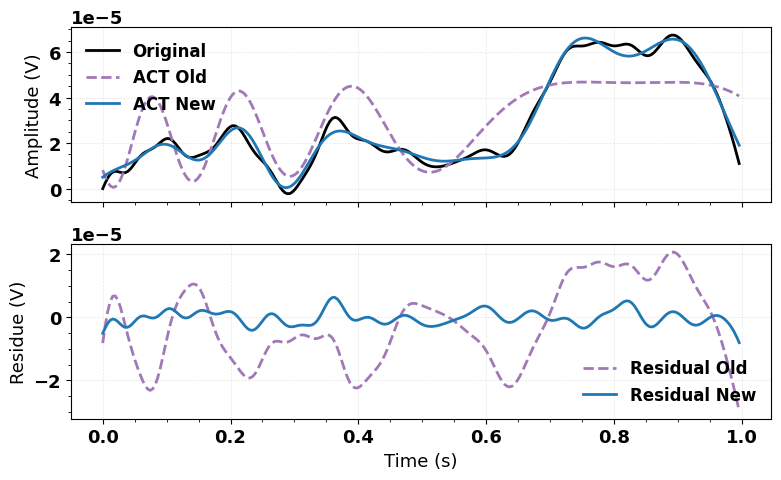

In [7]:
act_old = act_cpu_lib.ACT(FS=FS, length=epoch_length,
                          tc_info=tc_info, fc_info=fc_info,
                          logDt_info=logDt_info, c_info=c_info,
                          force_regenerate=True, mute=True)
act_new = act_cpu_lib_2.ACT(FS=FS, length=epoch_length,
                            tc_info=tc_info, fc_info=fc_info,
                            logDt_info=logDt_info, c_info=c_info,
                            force_regenerate=True, mute=True)
out_old = act_old.transform(segment,order=order, debug=False)
out_new = act_new.transform(segment,order=order, debug=False)
plt.rcParams.update({'font.size': 13})
fig,axs = plt.subplots(2,1,figsize=(8,5), sharex= True) 
axs[0].minorticks_on()
axs[0].grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.3)
axs[0].plot(t,out_old['signal'],label='Original', linewidth=2, color='black')
axs[0].plot(t,out_old['approx'],'--',label='ACT Old', linewidth=2, color="#A178B8")
axs[0].plot(t,out_new['approx'],label='ACT New', linewidth=2, color='tab:blue')
axs[0].set_ylabel('Amplitude (V)')
plt.tight_layout(h_pad=0.5)

axs[1].minorticks_on()
axs[1].grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.3)
axs[1].plot(t,out_old['residue'],'--',label='Residual Old', linewidth=2, color="#A178B8")
axs[1].plot(t,out_new['residue'],label='Residual New', linewidth=2, color='tab:blue')
axs[1].set_ylabel('Residue (V)')
axs[1].set_xlabel('Time (s)')
plt.tight_layout()

for ax in axs:
    ax.legend(frameon=False, fontsize=12)

plt.savefig('ACT_EEG.pdf', bbox_inches='tight')
plt.show()

## EMG Pipeline

In [8]:
from scipy.io import loadmat
from scipy.signal import iirnotch
FS = 2000
epoch_length = 200
order = 5
tc_info = (0,200,32)
fc_info = (20,450,10)
logDt_info = (-4,0,0.3)
c_info = (-10,10,0.75)

In [ ]:
mat = loadmat('../Data/S2_E3_A1_basic_movement.mat')
# print(mat.keys())
emg = mat['emg']

for freq in [50, 100, 150, 200, 250, 300, 350, 400, 450]:
    b_n, a_n = iirnotch(freq, Q=30, fs=FS)
    emg = filtfilt(b_n, a_n, emg, axis=0)
  
b, a = butter(4, [20/(FS/2), 450/(FS/2)], btype='band')
emg_filtered = np.zeros_like(emg)
for ch in range(emg.shape[1]):
    emg_filtered[:, ch] = filtfilt(b, a, emg[:, ch])
emg = emg_filtered

segment = emg[:epoch_length,0].astype(np.float32)
t = np.arange(len(segment))/FS

Dictionary length: 113778


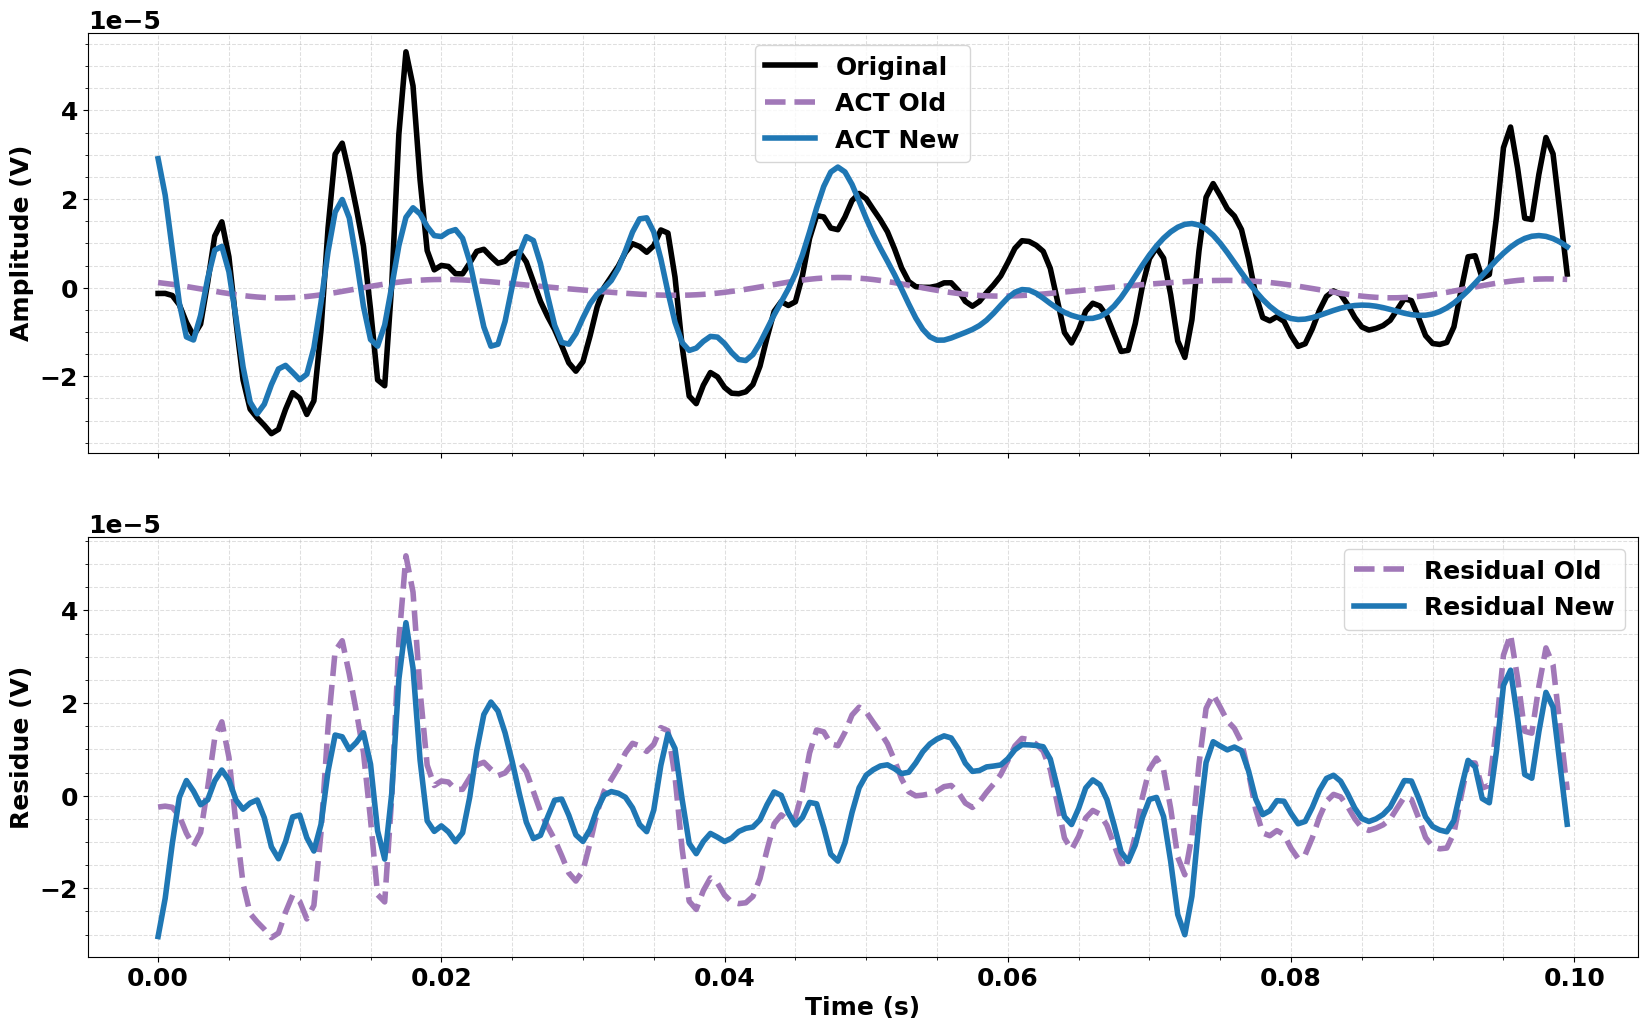

In [10]:
act_old = act_cpu_lib.ACT(FS=FS, length=epoch_length,
                          tc_info=tc_info, fc_info=fc_info,
                          logDt_info=logDt_info, c_info=c_info,
                          force_regenerate=True, mute=True)
act_new = act_cpu_lib_2.ACT(FS=FS, length=epoch_length,
                            tc_info=tc_info, fc_info=fc_info,
                            logDt_info=logDt_info, c_info=c_info,
                            force_regenerate=True, mute=True)
out_old = act_old.transform(segment,order=order, debug=False)
out_new = act_new.transform(segment,order=order, debug=False)
plt.rcParams.update({'font.size': 18, 'font.weight': 'bold'})
fig,axs = plt.subplots(2,1,figsize=(20,12), sharex= True)
axs[0].minorticks_on()
axs[0].grid(True, which='both', linestyle='--', linewidth=0.75, alpha=0.4)
axs[0].plot(t,out_old['signal'],label='Original', linewidth=4, color='black')
axs[0].plot(t,out_old['approx'],'--',label='ACT Old', linewidth=4, color="#A178B8")
axs[0].plot(t,out_new['approx'],label='ACT New', linewidth=4, color='tab:blue')
axs[0].set_ylabel('Amplitude (V)', fontweight='bold')

axs[1].minorticks_on()
axs[1].grid(True, which='both', linestyle='--', linewidth=0.75, alpha=0.4)
axs[1].plot(t,out_old['residue'],'--',label='Residual Old', linewidth=4, color="#A178B8")
axs[1].plot(t,out_new['residue'],label='Residual New', linewidth=4, color='tab:blue')
axs[1].set_ylabel('Residue (V)', fontweight='bold')
axs[1].set_xlabel('Time (s)', fontweight='bold')

for ax in axs:
    ax.legend()
plt.show()